# Classificação Binária com PyTorch

## Objetivos da aula

1. Construir um **Dataset** e um **DataLoader** customizados.
2. Treinar uma rede neural para **classificação binária** (Breast Cancer).
3. Usar o **TensorBoard** como interface web de acompanhamento.
4. Aprender a **salvar** e **carregar** modelos (persistência).

**Dataset:** Breast Cancer Wisconsin (scikit-learn) — 569 amostras, 30 features, rótulo binário (maligno / benigno).

## 1. Importando as bibliotecas

In [ ]:
!pip install numpy matplotlib scikit-learn

In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
!pip install tensorboard

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Reprodutibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

Usando device: cpu


## 2. Carregando os dados

O dataset **Breast Cancer** contém 30 features numéricas calculadas a partir de imagens digitalizadas de biópsias. O rótulo indica se o tumor é maligno (0) ou benigno (1).

In [6]:
dados = load_breast_cancer()
X, y = dados.data, dados.target

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Classes: {dados.target_names}")
print(f"Distribuição: {np.bincount(y)}")

# Normalização
scaler = StandardScaler()
X = scaler.fit_transform(X)

Formato de X: (569, 30)
Formato de y: (569,)
Classes: ['malignant' 'benign']
Distribuição: [212 357]


## 3. Dataset customizado

Toda classe que herda de `torch.utils.data.Dataset` deve implementar:

- `__len__` → tamanho do dataset
- `__getitem__` → devolve a i-ésima amostra `(x, y)`

In [11]:
class BreastCancerDataset(Dataset):
    """Dataset customizado para classificação binária."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # y em float e com shape [N, 1] para casar com BCEWithLogitsLoss
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = BreastCancerDataset(X, y)
print(f"Tamanho do dataset: {len(dataset)}")
print(f"Exemplo 0 - X shape: {dataset[0][0].shape}, y: {dataset[0][1]}")

Tamanho do dataset: 569
Exemplo 0 - X shape: torch.Size([30]), y: tensor([0.])


## 4. DataLoader

O `DataLoader` cuida de:
- **Batching** (agrupar amostras)
- **Shuffling** (embaralhar a cada época)
- **Paralelismo** via `num_workers`

In [123]:
# Divisão 70/15/15
n_total = len(dataset)
n_treino = int(0.70 * n_total)
n_val    = int(0.15 * n_total)
n_teste  = n_total - n_treino - n_val

treino_ds, val_ds, teste_ds = random_split(
    dataset, [n_treino, n_val, n_teste],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Treino: {len(treino_ds)} | Val: {len(val_ds)} | Teste: {len(teste_ds)}")

BATCH = 32
train_loader = DataLoader(treino_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,    batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(teste_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

# Inspecionar um batch
Xb, yb = next(iter(train_loader))
print(f"Batch X: {Xb.shape} | Batch y: {yb.shape}")

Treino: 398 | Val: 85 | Teste: 86
Batch X: torch.Size([32, 30]) | Batch y: torch.Size([32, 1])


## 5. Definindo o modelo

In [124]:
class ClassificadorBinario(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)  # saída em LOGITS — sem sigmoide
        )

    def forward(self, x):
        return self.rede(x)


modelo = ClassificadorBinario(n_features=X.shape[1]).to(device)
print(modelo)

n_params = sum(p.numel() for p in modelo.parameters())
print(f"\nTotal de parâmetros: {n_params:,}")

ClassificadorBinario(
  (rede): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros: 4,097


## 6. Função de perda e otimizador

Usamos `BCEWithLogitsLoss` que é **numericamente mais estável** do que aplicar `Sigmoid + BCELoss` separadamente.

In [125]:
criterio = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(modelo.parameters(), lr=1e-3, weight_decay=1e-5)

## 7. TensorBoard

`SummaryWriter` grava logs em um diretório. Depois do treino, abrimos a interface web com:

```bash
tensorboard --logdir=runs --port=6006
```

Ou dentro do notebook:

```python
%load_ext tensorboard
%tensorboard --logdir runs
```

In [126]:
writer = SummaryWriter(log_dir="runs/binaria_breast_cancer")

## 8. Loop de treinamento

In [127]:
def treinar_epoca(modelo, loader, criterio, optimizer, device):
    modelo.train()
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = modelo(Xb)
        loss = criterio(logits, yb)
        loss.backward()
        optimizer.step()

        loss_total += loss.item() * Xb.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        acertos += (preds == yb).sum().item()
        total   += yb.size(0)
    return loss_total/total, acertos/total


def avaliar(modelo, loader, criterio, device):
    modelo.eval()
    loss_total, acertos, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = modelo(Xb)
            loss = criterio(logits, yb)
            loss_total += loss.item() * Xb.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            acertos += (preds == yb).sum().item()
            total   += yb.size(0)
    return loss_total/total, acertos/total

In [128]:
N_EPOCAS = 50
historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
melhor_val_loss = float("inf")

for epoca in range(1, N_EPOCAS + 1):
    tr_loss, tr_acc = treinar_epoca(modelo, train_loader, criterio, optimizer, device)
    vl_loss, vl_acc = avaliar(modelo, val_loader, criterio, device)

    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["train_acc"].append(tr_acc)
    historico["val_acc"].append(vl_acc)

    # --- TensorBoard ---
    writer.add_scalars("Loss", {"treino": tr_loss, "val": vl_loss}, epoca)
    writer.add_scalars("Acuracia", {"treino": tr_acc, "val": vl_acc}, epoca)
    for nome, param in modelo.named_parameters():
        writer.add_histogram(nome, param, epoca)

    # --- Checkpoint do melhor modelo ---
    if vl_loss < melhor_val_loss:
        melhor_val_loss = vl_loss
        torch.save({
            "epoca": epoca,
            "modelo_state": modelo.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": vl_loss,
        }, "melhor_modelo_binario.pth")

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:02d} | treino loss={tr_loss:.4f} acc={tr_acc:.4f} "
              f"| val loss={vl_loss:.4f} acc={vl_acc:.4f}")

writer.close()
print("\nTreinamento concluído!")

Época 01 | treino loss=0.6386 acc=0.7915 | val loss=0.5625 acc=0.9294
Época 05 | treino loss=0.1718 acc=0.9648 | val loss=0.0996 acc=0.9765
Época 10 | treino loss=0.0663 acc=0.9824 | val loss=0.0429 acc=0.9882
Época 15 | treino loss=0.0523 acc=0.9849 | val loss=0.0319 acc=0.9882
Época 20 | treino loss=0.0399 acc=0.9950 | val loss=0.0305 acc=0.9882
Época 25 | treino loss=0.0330 acc=0.9925 | val loss=0.0316 acc=0.9882
Época 30 | treino loss=0.0285 acc=0.9950 | val loss=0.0307 acc=0.9882
Época 35 | treino loss=0.0231 acc=0.9899 | val loss=0.0302 acc=0.9882
Época 40 | treino loss=0.0231 acc=0.9925 | val loss=0.0345 acc=0.9882
Época 45 | treino loss=0.0168 acc=0.9975 | val loss=0.0394 acc=0.9882
Época 50 | treino loss=0.0174 acc=0.9950 | val loss=0.0351 acc=0.9882

Treinamento concluído!


## 9. Gráficos de treinamento

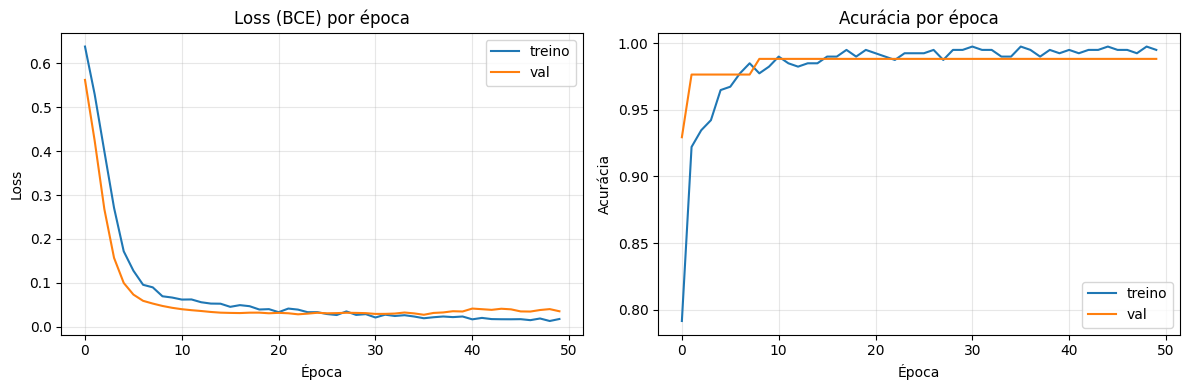

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historico["train_loss"], label="treino")
axes[0].plot(historico["val_loss"], label="val")
axes[0].set_title("Loss (BCE) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(historico["train_acc"], label="treino")
axes[1].plot(historico["val_acc"], label="val")
axes[1].set_title("Acurácia por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Carregando o **melhor** modelo salvo e avaliando no teste

Aqui demonstramos a **persistência**: recriamos a arquitetura e carregamos os pesos salvos do melhor checkpoint.

In [130]:
# Recriamos a arquitetura e carregamos os pesos
modelo_final = ClassificadorBinario(n_features=X.shape[1]).to(device)

checkpoint = torch.load("melhor_modelo_binario.pth", map_location=device)
modelo_final.load_state_dict(checkpoint["modelo_state"])
modelo_final.eval()

print(f"Checkpoint da época {checkpoint['epoca']} | val_loss={checkpoint['val_loss']:.4f}")

Checkpoint da época 36 | val_loss=0.0270


In [131]:
# Avaliação final no conjunto de teste
all_y, all_pred, all_prob = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = modelo_final(Xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_y.extend(yb.numpy().flatten())
        all_pred.extend(preds.flatten())
        all_prob.extend(probs.flatten())

all_y = np.array(all_y)
all_pred = np.array(all_pred)
all_prob = np.array(all_prob)

acc = accuracy_score(all_y, all_pred)
cm  = confusion_matrix(all_y, all_pred)
print(f"Acurácia no teste: {acc:.4f}")
print(f"Matriz de confusão:\n{cm}")

Acurácia no teste: 0.9535
Matriz de confusão:
[[36  2]
 [ 2 46]]


## 11. Visualizações da avaliação

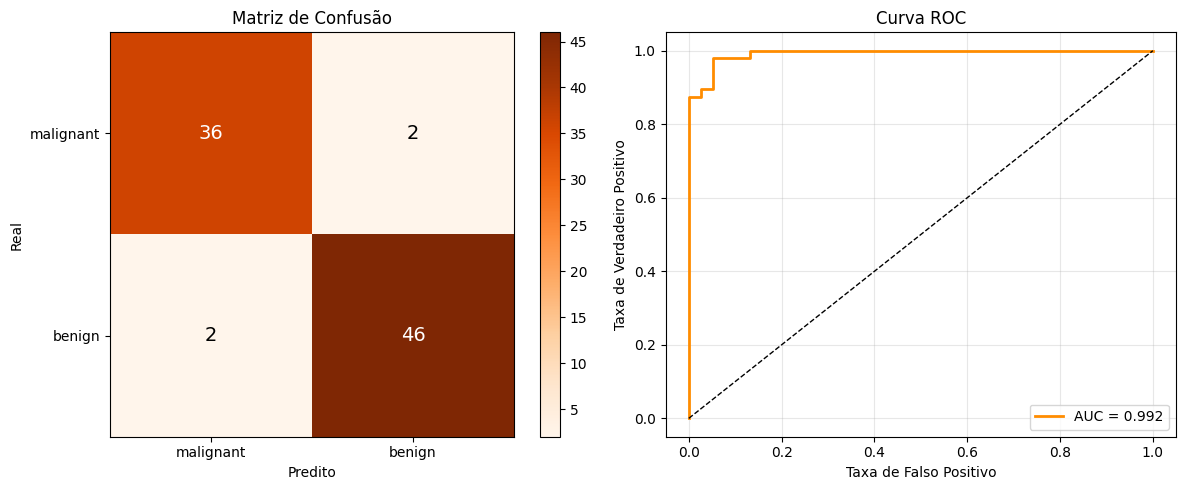

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusão
im = axes[0].imshow(cm, cmap="Oranges")
axes[0].set_title("Matriz de Confusão")
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(dados.target_names)
axes[0].set_yticklabels(dados.target_names)
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=axes[0])

# Curva ROC
fpr, tpr, _ = roc_curve(all_y, all_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Abrindo o TensorBoard

Execute em um terminal, dentro da pasta deste notebook:

```bash
tensorboard --logdir=runs --port=6006
```

Depois abra **http://localhost:6006** no navegador. Lá você verá:
- **Scalars**: curvas de `Loss/treino`, `Loss/val`, `Acuracia/treino`, `Acuracia/val`
- **Histograms**: distribuição dos pesos a cada época

Para abrir **dentro** do notebook:

In [4]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 17164), started 0:02:25 ago. (Use '!kill 17164' to kill it.)

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir runs

## Resumo

- Criamos um **Dataset** herdando de `torch.utils.data.Dataset`.
- Usamos **DataLoader** com `shuffle=True` no treino.
- Treinamos um classificador binário com `BCEWithLogitsLoss`.
- **Persistimos** o melhor modelo com `torch.save` e recarregamos com `load_state_dict`.
- Monitoramos tudo pelo **TensorBoard**.
- Avaliamos com **matriz de confusão** e **curva ROC**.